In [12]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.preprocessing import MinMaxScaler # for scaling data
import seaborn as sns # visualisation
import matplotlib.pyplot as plt # visualisation
from sklearn.linear_model import LinearRegression # Linear regression model
from sklearn.metrics import mean_squared_error # MSE calculation
from sklearn.feature_selection import RFE # backward selection
from sklearn.model_selection import train_test_split

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

train_data = pd.read_csv('/kaggle/input/playground-series-s3e6/train.csv')
test_data = pd.read_csv('/kaggle/input/playground-series-s3e6/test.csv')

/kaggle/input/playground-series-s3e6/sample_submission.csv
/kaggle/input/playground-series-s3e6/train.csv
/kaggle/input/playground-series-s3e6/test.csv


Once all the data and necessary packages are loaded, we perform exploratory data analysis. 
1. Take a look at the data
2. Check data typs, formats and look for missing values
3. Change data types whenever necessary. Here we decide to change only the type of cityCode column
4. Define a complete list of features

Note that the project specifically says it has to be a linear regression model, thus the other possible regression techniques (including random forest) are not implemented.

In [13]:
train_data.head()

,id,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price
0,0,34291,24,1,0,47,35693,2,1,2000,0,1,8,5196,369,0,3,3436795.2
1,1,95145,60,0,1,60,34773,1,4,2000,0,1,729,4496,277,0,6,9519958.0
2,2,92661,45,1,1,62,45457,4,8,2020,1,1,7473,8953,245,1,9,9276448.1
3,3,97184,99,0,0,59,15113,1,1,2000,0,1,6424,8522,256,1,9,9725732.2
4,4,61752,100,0,0,57,64245,8,4,2018,1,0,7151,2786,863,0,7,6181908.8


In [14]:
train_data.info() # no null values or missing values
train_data['cityCode'] = train_data['cityCode'].astype('category')
test_data['cityCode'] = test_data['cityCode'].astype('category')
features = train_data.columns[1:-1]
print(features)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22730 entries, 0 to 22729
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 22730 non-null  int64  
 1   squareMeters       22730 non-null  int64  
 2   numberOfRooms      22730 non-null  int64  
 3   hasYard            22730 non-null  int64  
 4   hasPool            22730 non-null  int64  
 5   floors             22730 non-null  int64  
 6   cityCode           22730 non-null  int64  
 7   cityPartRange      22730 non-null  int64  
 8   numPrevOwners      22730 non-null  int64  
 9   made               22730 non-null  int64  
 10  isNewBuilt         22730 non-null  int64  
 11  hasStormProtector  22730 non-null  int64  
 12  basement           22730 non-null  int64  
 13  attic              22730 non-null  int64  
 14  garage             22730 non-null  int64  
 15  hasStorageRoom     22730 non-null  int64  
 16  hasGuestRoom       227

In [15]:
train_data.describe()

,id,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price
count,22730.000000,2.273000e+04,22730.000000,22730.000000,22730.000000,22730.000000,22730.000000,22730.000000,22730.000000,22730.000000,22730.000000,22730.000000,22730.000000,22730.000000,22730.000000,22730.000000,2.273000e+04
mean,11364.500000,4.658622e+04,48.241091,0.475891,0.452750,47.305983,5.585042,5.620766,2008.005059,0.467972,0.460009,5283.646634,5067.981698,530.469644,0.461681,5.153058,4.634457e+06
std,6561.730145,4.952124e+04,28.226428,0.499429,0.497773,47.777207,2.739533,2.713026,118.826777,0.498984,0.498409,3047.084412,3097.347939,274.840604,0.498540,3.055246,2.925163e+06
min,0.000000,8.900000e+01,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1990.000000,0.000000,0.000000,4.000000,1.000000,4.000000,0.000000,0.000000,1.031350e+04
25%,5682.250000,2.039275e+04,25.000000,0.000000,0.000000,25.000000,3.000000,3.000000,2000.000000,0.000000,0.000000,2977.250000,2599.000000,297.000000,0.000000,3.000000,2.041739e+06
50%,11364.500000,4.448400e+04,47.000000,0.000000,0.000000,45.000000,6.000000,6.000000,2006.000000,0.000000,0.000000,5359.000000,4977.000000,515.000000,0.000000,5.000000,4.450823e+06
75%,17046.750000,7.154700e+04,75.000000,1.000000,1.000000,69.000000,8.000000,8.000000,2014.000000,1.000000,1.000000,7746.000000,7652.000000,767.000000,1.000000,8.000000,7.159920e+06
max,22729.000000,6.071330e+06,100.000000,1.000000,1.000000,6000.000000,10.000000,10.000000,10000.000000,1.000000,1.000000,91992.000000,96381.000000,9017.000000,1.000000,10.000000,1.000428e+07


Now once we have an idea about the data, lets take a look at some visualisations to:
1. Identify outliers
2. See possible existing patterns

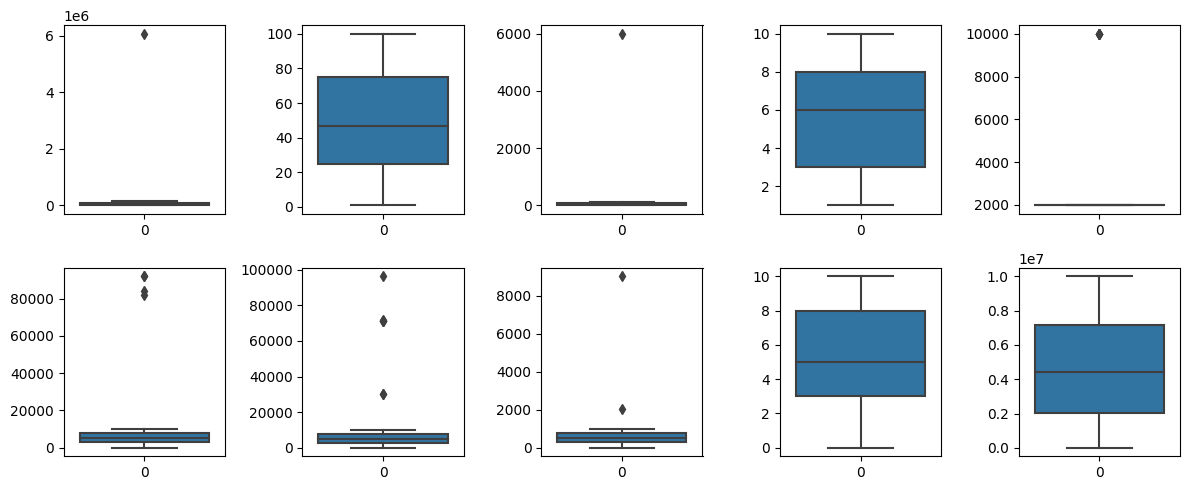

In [16]:
# Boxplots to identify outliers
fig, axes = plt.subplots(2,5, figsize = (12,5))
plt1 = sns.boxplot(train_data['squareMeters'], ax = axes[0,0])
plt2 = sns.boxplot(train_data['numberOfRooms'], ax = axes[0,1])
plt3 = sns.boxplot(train_data['floors'], ax = axes[0,2])
plt4 = sns.boxplot(train_data['numPrevOwners'], ax = axes[0,3])
plt5 = sns.boxplot(train_data['made'], ax = axes[0,4])
plt6 = sns.boxplot(train_data['basement'], ax = axes[1,0])
plt7 = sns.boxplot(train_data['attic'], ax = axes[1,1])
plt8 = sns.boxplot(train_data['garage'], ax = axes[1,2])
plt9 = sns.boxplot(train_data['hasGuestRoom'], ax = axes[1,3])
plt10 = sns.boxplot(train_data['price'], ax = axes[1,4])
plt.tight_layout()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

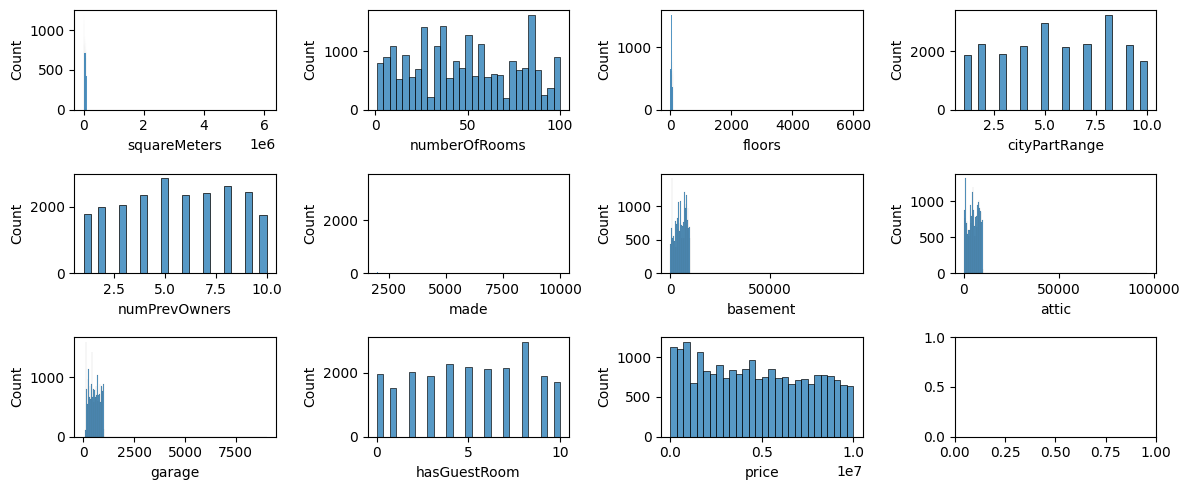

In [17]:
# Histograms
hist_vars = ['squareMeters', 'numberOfRooms', 'floors', 'cityPartRange', 'numPrevOwners', 'made',
             'basement', 'attic', 'garage', 'hasGuestRoom', 'price']
fig, axes = plt.subplots(3,4, figsize = (12,5))
for i in range(len(hist_vars)):
    sns.histplot(train_data[hist_vars[i]], ax = axes[i//4, i%4])
plt.tight_layout()
plt.show()

The easiest method to remove outliers is to use 1.5*IQR rule:

The new shape of the data:  (22710, 18)


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

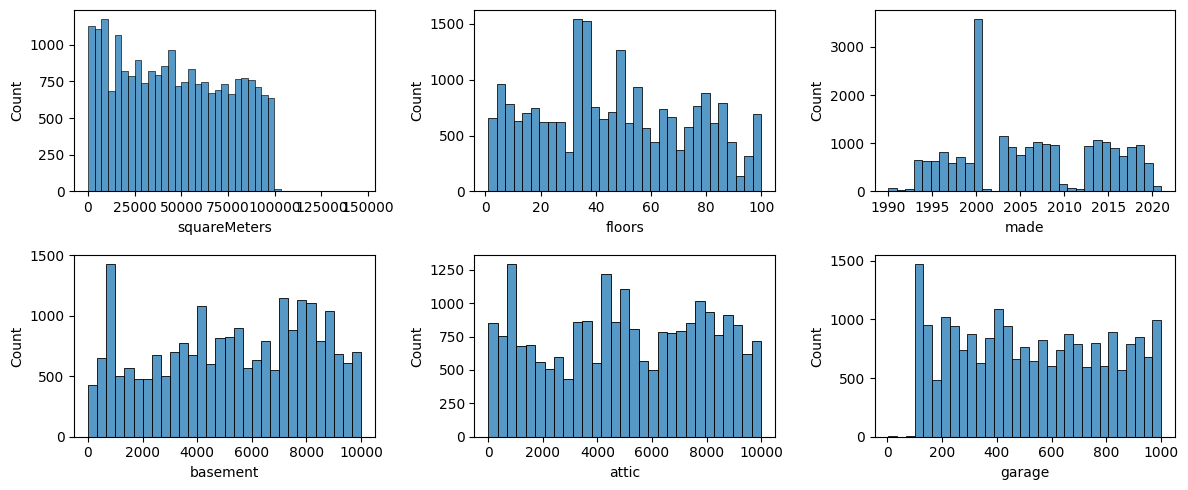

In [18]:
# Remove outliers
outlier_vars = ['squareMeters', 'floors', 'made', 'basement', 'attic', 'garage']

for val in outlier_vars:
    q3 = train_data[val].quantile(0.75)
    q1 = train_data[val].quantile(0.25)
    iqr = q3 - q1
    train_data = train_data[(train_data[val]<= q3+ 1.5*iqr) & (train_data[val]>= q1 - 1.5*iqr) ]
print("The new shape of the data: ", train_data.shape)
## Updated histograms
fig, axes = plt.subplots(2,3, figsize = (12,5))
for i in range(len(outlier_vars)):
    sns.histplot(train_data[outlier_vars[i]], ax = axes[i//3, i%3])
plt.tight_layout()
plt.show()

Note that the boolean type features (hasYard, hasPool, etc) as well as categorical type features (is, cityCode) are not included intentionally. We see above that the total number of outliers across the selected features are 20. Since we have enough data, we can simply eliminate the outliers.

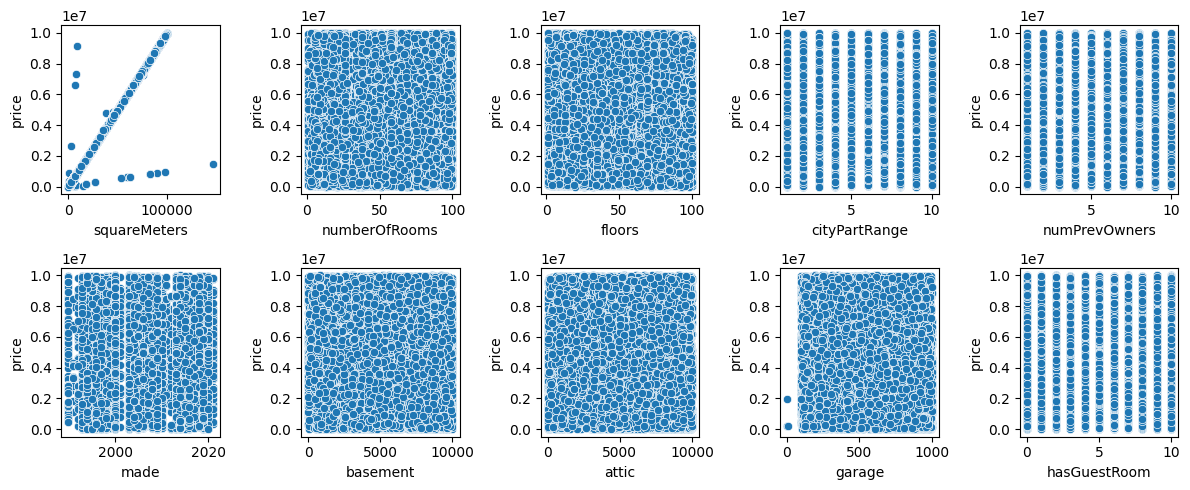

In [19]:
# Plot features agains the price
plot_vars = ['squareMeters', 'numberOfRooms', 'floors', 'cityPartRange', 'numPrevOwners', 'made', 'basement', 
             'attic', 'garage', 'hasGuestRoom']
fig, axes = plt.subplots(2,5, figsize = (12,5))
for i in range(len(plot_vars)):
    sns.scatterplot(train_data, x = plot_vars[i], y='price', ax = axes[i//5, i%5])
plt.tight_layout()
plt.show()

From the scatterplots above we only wee the clear pattern in the linear relationship betwene price and square meters.
Let's see if there are measurable correlations between the variable of interest and its covariates.

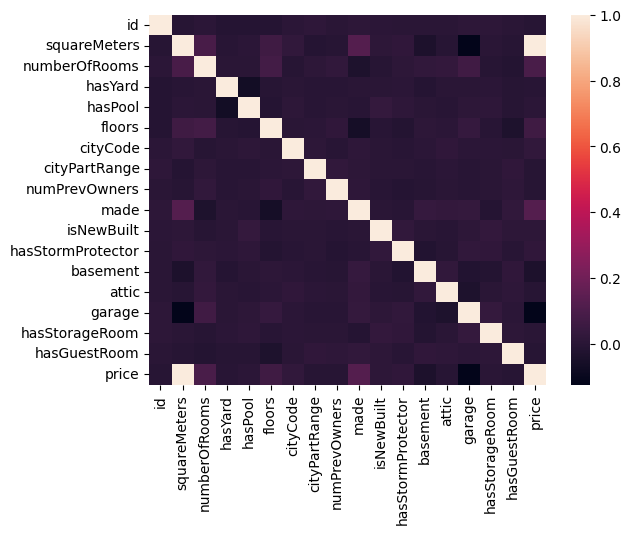

In [20]:
corrMat = train_data.corr()
sns.heatmap(corrMat)
plt.show()

There are some correlation between the floors and squareMeters and numberOfRooms and between the latter two, which is quite logical. Some correlation between made and squareMeters, and garage and numberOfRooms, which are not as straightforward. Let's explore further with the pairplots:

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

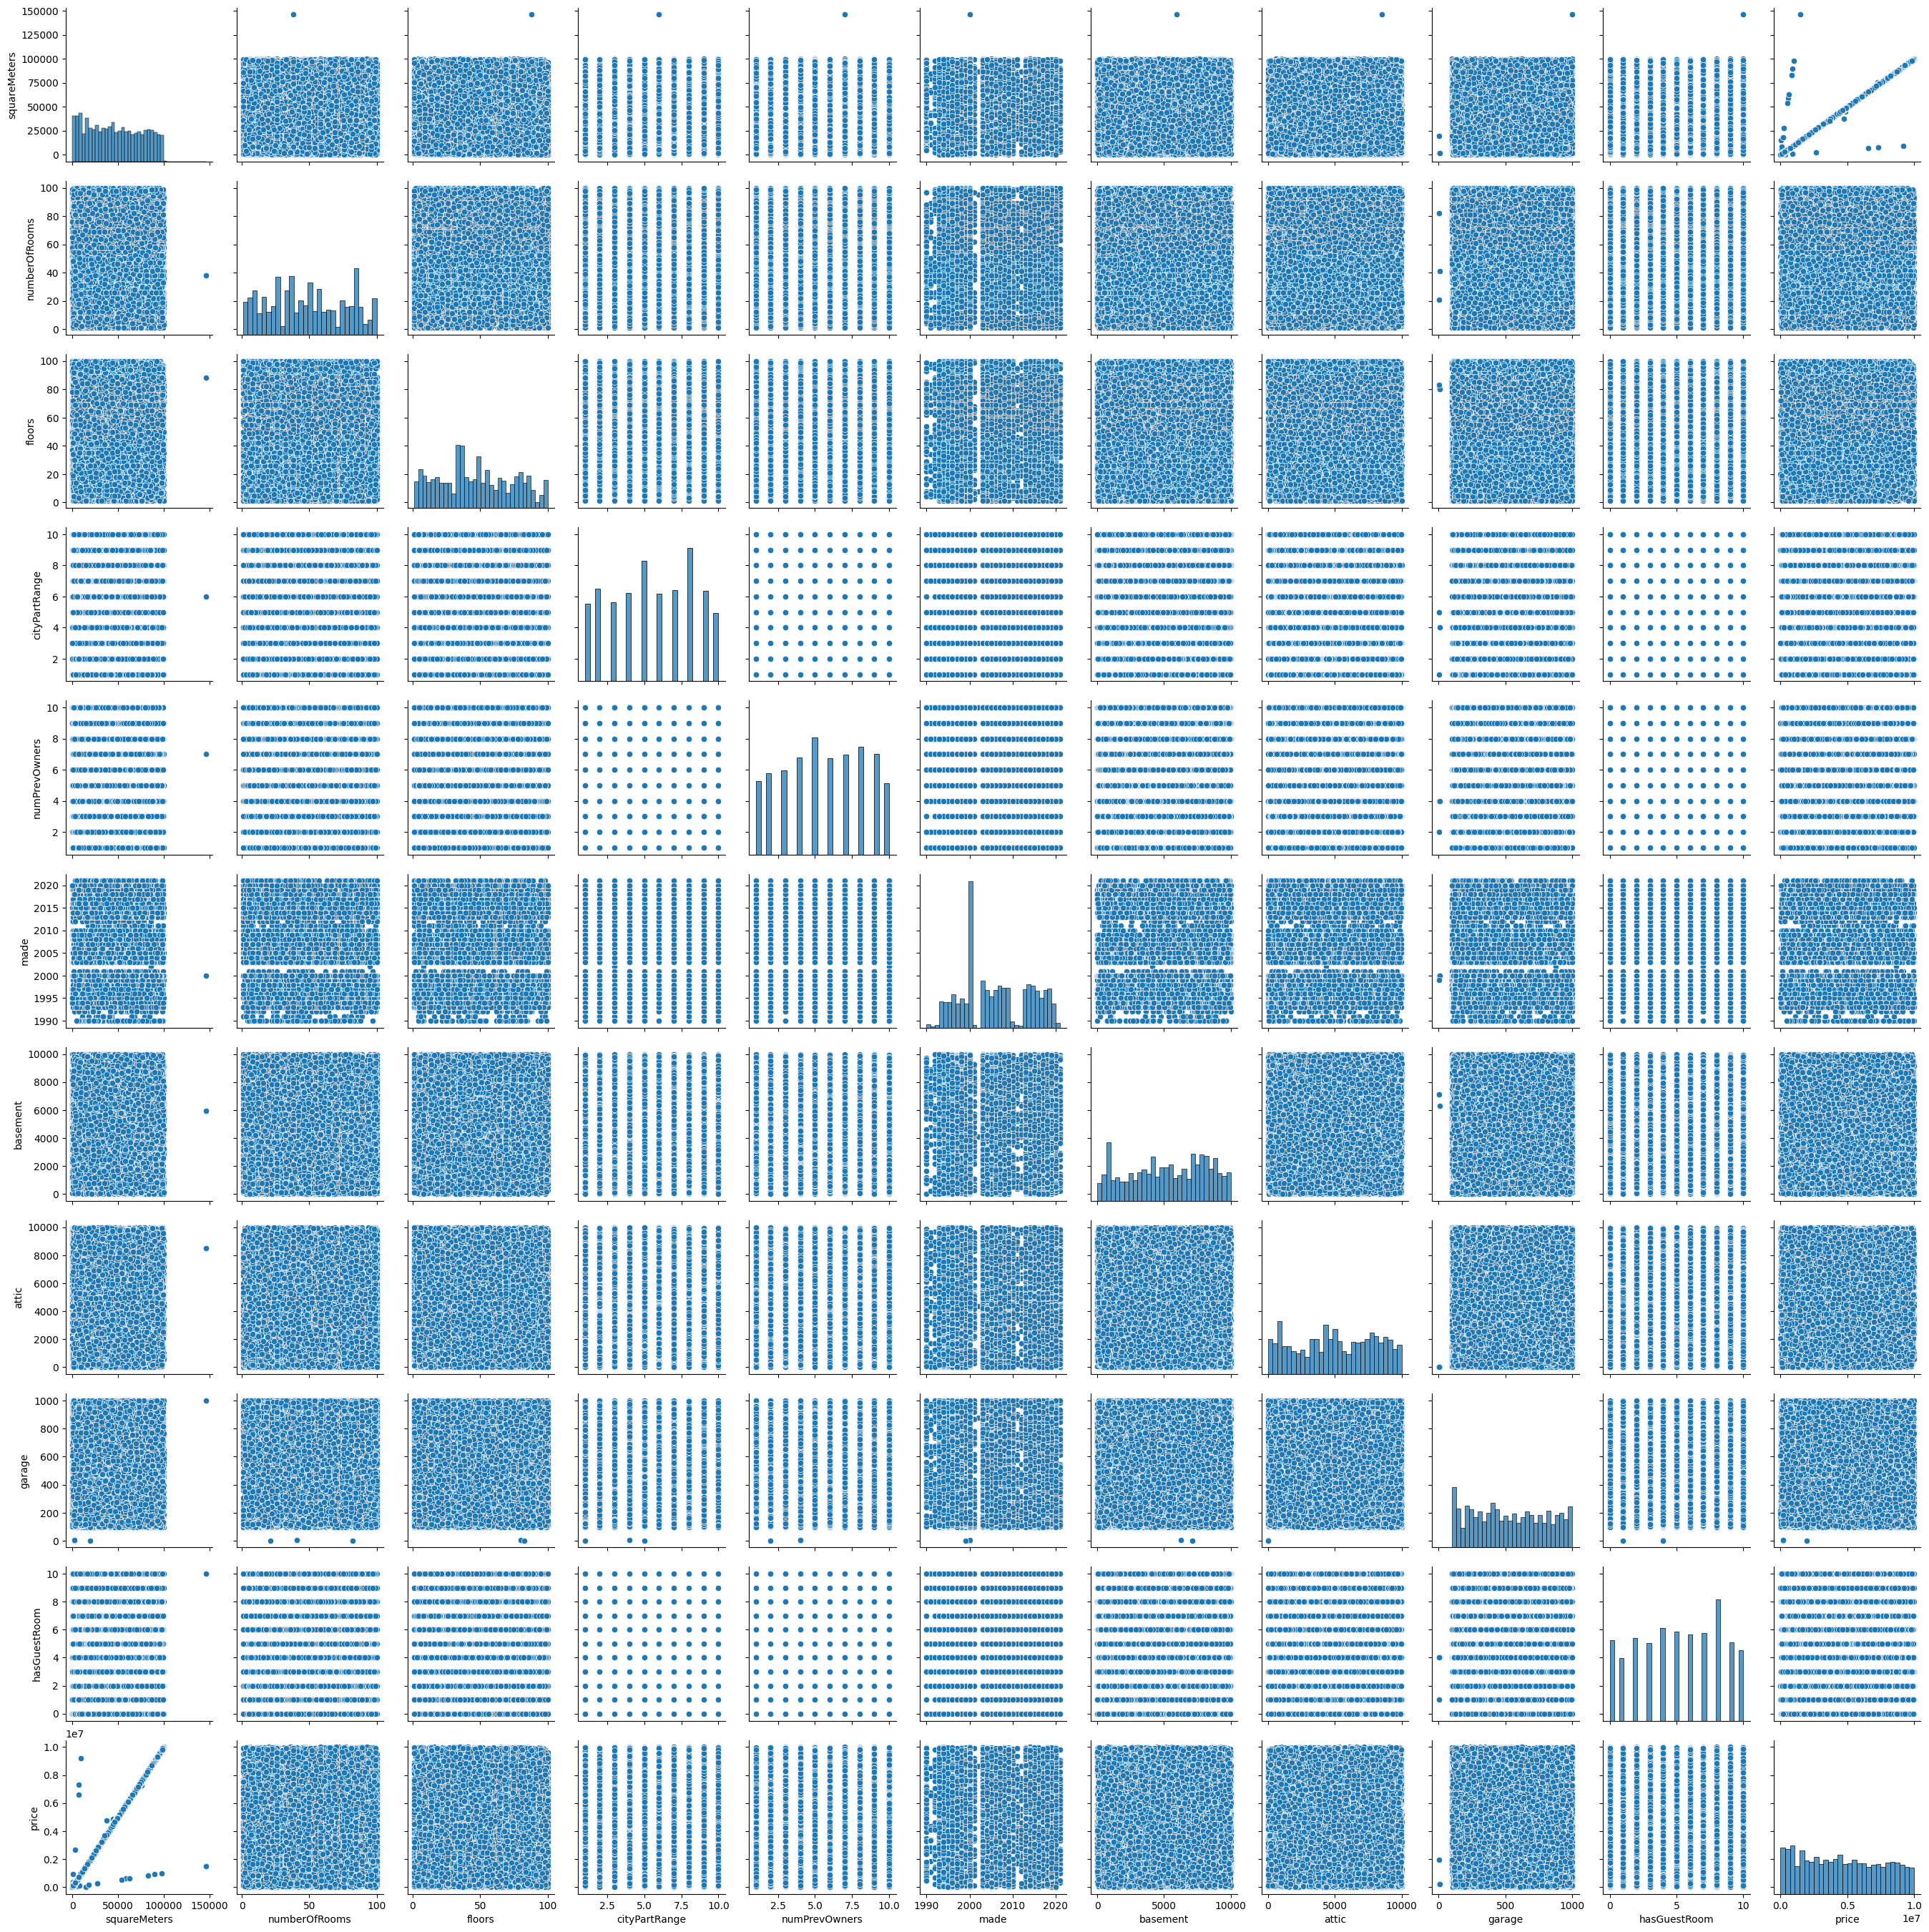

In [21]:
# Preclean for pairplot
train_data.replace([np.inf, -np.inf], np.nan, inplace=True)
train_data.dropna(inplace=True)

num_vars = ['squareMeters', 'numberOfRooms', 'floors', 'cityPartRange', 'numPrevOwners', 'made',
            'basement', 'attic', 'garage','hasGuestRoom', 'price']
sns.pairplot(train_data[num_vars])
plt.show()

We see that some of the columns has much wider range than others. To avoid these features dominating the model, we perform rescaling. Additionally, since we have to use the parameters trained on the rescaled model to perform predistion on the test data, we perform rescaling on the test data too.

In [22]:
scaler_vars = ['squareMeters', 'numberOfRooms', 'floors',
               'basement', 'attic', 'garage'] # covariates
scaler = MinMaxScaler()
train_data[scaler_vars] = scaler.fit_transform(train_data[scaler_vars])
test_data[scaler_vars] = scaler.transform(test_data[scaler_vars])
# Response variable
pmax = max(train_data['price'])
pmin = min(train_data['price'])
train_data['price'] = (train_data['price'] - pmin)/(pmax - pmin)

Now we perform covariate selection using backward selection method. To assess the model we split the data (75-25) into training and testing sets and assess the model resibuals on a testing set.

In [23]:
selected_features = ['squareMeters', 'numberOfRooms', 'hasYard', 'hasPool', 'floors', 'cityPartRange',
                     'numPrevOwners', 'made', 'isNewBuilt','hasStormProtector', 'basement', 'attic',
                     'garage', 'hasStorageRoom', 'hasGuestRoom'] 
X = train_data[selected_features]
y = train_data['price']
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.75, random_state = 123)

model = LinearRegression()
selector = RFE(model)
selector.fit(X_train, y_train)
rfe_features = selector.get_feature_names_out()
print("Seleted features are: ", rfe_features)
y_pred = selector.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_pred, y_test))
print("The model RMSE is: ", rmse)

Seleted features are:  ['squareMeters' 'numberOfRooms' 'hasPool' 'basement' 'attic' 'garage'
 'hasStorageRoom']
The model RMSE is:  0.021524198014553398


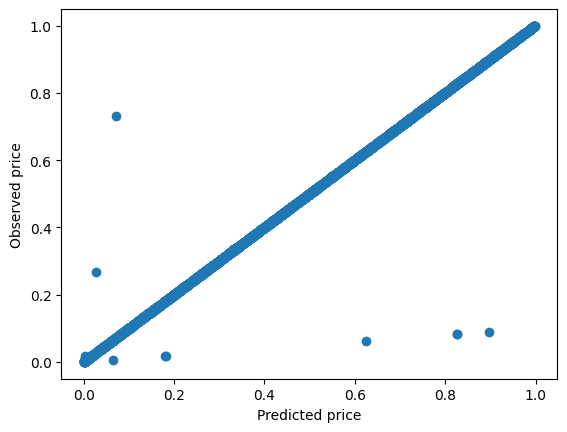

In [24]:
plt.scatter(y_pred,y_test)
plt.xlabel("Predicted price")
plt.ylabel("Observed price")
plt.show()

We have achieved a pretty decent fit using backward selection. Let's check other model properties

In [27]:
X_rfe = X_train[selector.get_feature_names_out()]

import statsmodels.api as sm  
X_rfe_fin = sm.add_constant(X_rfe)
finmod = sm.OLS(y_train, X_rfe).fit()
print(finmod.summary())

                                 OLS Regression Results                                
Dep. Variable:                  price   R-squared (uncentered):                   0.999
Model:                            OLS   Adj. R-squared (uncentered):              0.999
Method:                 Least Squares   F-statistic:                          1.796e+06
Date:                Wed, 30 Apr 2025   Prob (F-statistic):                        0.00
Time:                        17:18:36   Log-Likelihood:                          42365.
No. Observations:               17032   AIC:                                 -8.472e+04
Df Residuals:                   17025   BIC:                                 -8.466e+04
Df Model:                           7                                                  
Covariance Type:            nonrobust                                                  
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

Both R^2 and adjusted R^2 are extremely close to one indicating that almost all the variance in the training data is explained by the covariates. We also see a very high F-statitsics suggesting significant relation between the independent and dependent variables.

In [35]:
X_pred_rfe = test_data[selected_features]
y_out = selector.predict(X_pred_rfe)
submission_data = pd.DataFrame({'id':test_data['id'], 'price': (y_out*(pmax-pmin) + pmin)})
submission_data.to_csv('submission.csv', index=False)